In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('../Trial_files/5Volt_inputTEST.csv')


In [32]:
df.columns

Index(['VoltageP1', 'VoltageP2', 'TimeIndex'], dtype='str')

In [33]:
df.columns = ['v1', 'v2', 'time']
df.columns

Index(['v1', 'v2', 'time'], dtype='str')

In [7]:
#df.time = pd.to_datetime(df['time'], unit='s')
#df = df.set_index('time')

In [35]:
df.shape[0]/(df.time.iloc[-1] - df.time.iloc[0])

np.float64(9.905704091160763)

In [41]:
uniform_time = np.linspace(df['time'].iloc[0], df['time'].iloc[-1], df.shape[0])
p1_resampled = np.interp(uniform_time, df['time'], df['v1'])
p2_resampled = np.interp(uniform_time, df['time'], df['v2'])

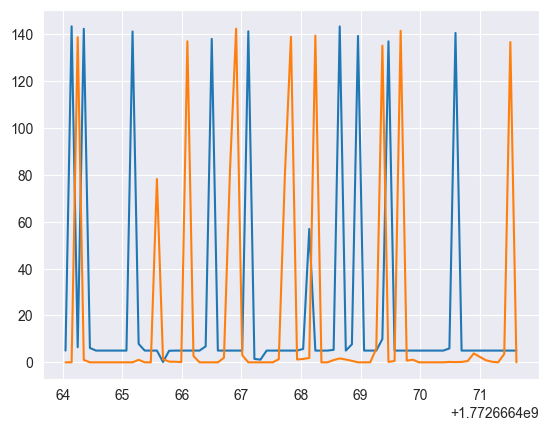

In [42]:
plt.plot(uniform_time, p1_resampled, label='p1')
plt.plot(uniform_time, p2_resampled, label='p2')

In [70]:
df.columns

Index(['v1', 'v2'], dtype='str')

<Axes: xlabel='time', ylabel='v2'>

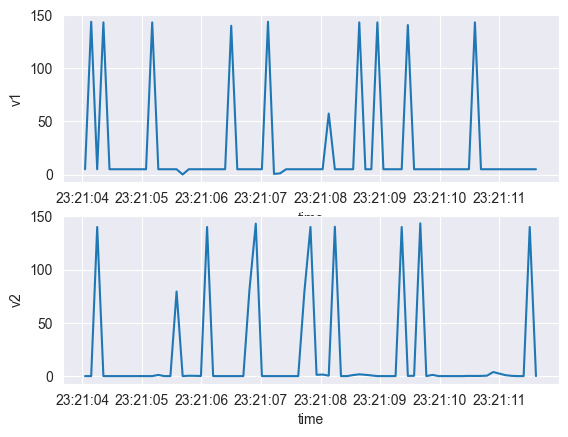

In [71]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)
sns.lineplot(df, x='time', y='v1', ax=ax1, errorbar=None)
sns.lineplot(df, x='time', y='v2', ax=ax2, errorbar=None)

In [74]:
print(f'Abnormal v1%: {df[df.v1>5.1].shape[0] /df.shape[0]}')
print(f'Abnormal v2%: {df[df.v2>5].shape[0] /df.shape[0]}')

Abnormal v1%: 0.13333333333333333
Abnormal v2%: 0.14666666666666667


In [86]:
df[df.v1>5].reset_index().time

0   2026-03-04 23:21:04.148323298
1   2026-03-04 23:21:04.353315592
2   2026-03-04 23:21:05.172694683
3   2026-03-04 23:21:06.499513149
4   2026-03-04 23:21:07.117067575
5   2026-03-04 23:21:08.137195110
6   2026-03-04 23:21:08.649844170
7   2026-03-04 23:21:08.953795910
8   2026-03-04 23:21:09.465382099
9   2026-03-04 23:21:10.591783524
Name: time, dtype: datetime64[ns]